# **Ievads attēlu apstrādē**

## **Praktiskais darbs Nr. 5**

---

**Students:** Edgars Polis

**Studenta apliecības Nr.:** 241RDB296

**Saite uz programmēšanas kodu:** https://github.com/Edgars-P/RTU_IAA_MD/blob/main/LD5/IAA_LD5.ipynb

---

**Variants 6**

- Gausa adaptīvā sliekšņošana
- K-Means (klasteru skaitu var izvēlēties jebkuru)


## **Programmas kods ar izvadi**


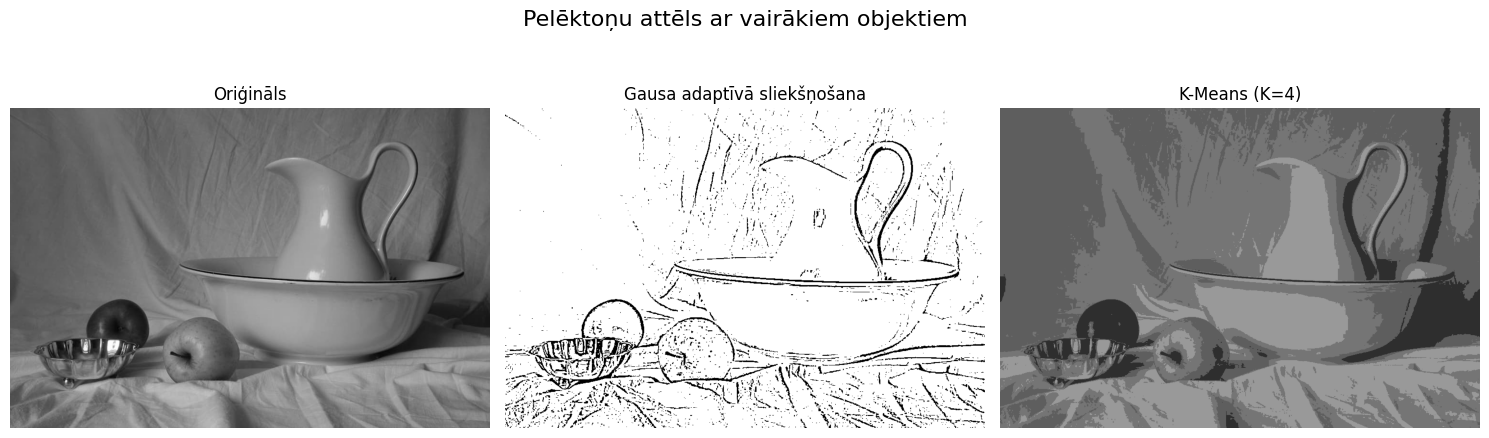

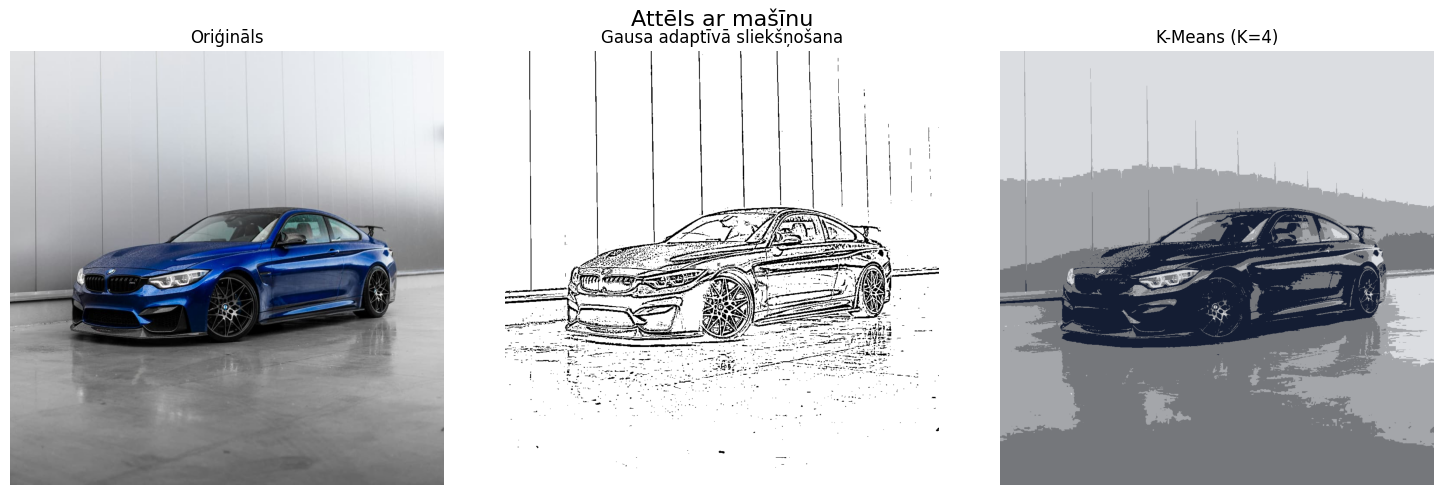

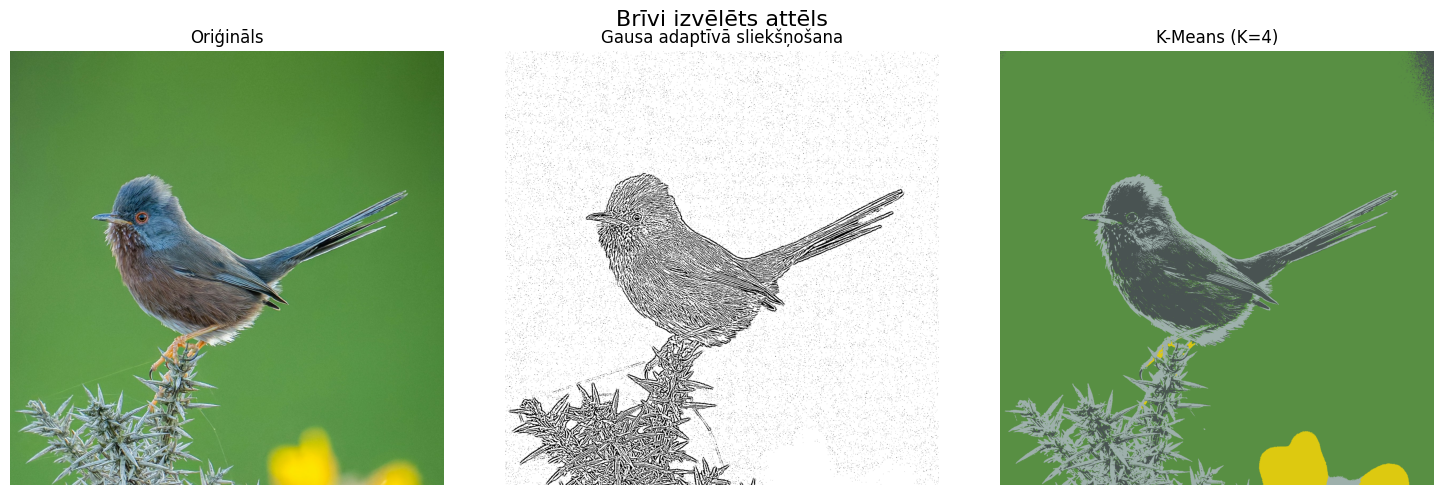

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def apply_gaussian_adaptive(image_gray):
    return cv2.adaptiveThreshold(
        image_gray, 
        255, 
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY, 
        15, 
        5
    )

def apply_kmeans(image, k):
    pixel_values = image.reshape((-1, 3))
    pixel_values = np.float32(pixel_values)
    
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    _, labels, centers = cv2.kmeans(
        pixel_values, 
        k, 
        None, 
        criteria, 
        10, 
        cv2.KMEANS_RANDOM_CENTERS
    )
    
    centers = np.uint8(centers)
    segmented_data = centers[labels.flatten()]
    return segmented_data.reshape(image.shape)

def process_and_display(image_path, title, k_clusters=3):
    img_bgr = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    
    adaptive_thresh_result = apply_gaussian_adaptive(img_gray)
    kmeans_result = apply_kmeans(img_rgb, k_clusters)
    
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    
    axs[0].imshow(img_rgb)
    axs[0].set_title("Oriģināls")
    axs[0].axis("off")
    
    axs[1].imshow(adaptive_thresh_result, cmap='gray')
    axs[1].set_title("Gausa adaptīvā sliekšņošana")
    axs[1].axis("off")
    
    axs[2].imshow(kmeans_result)
    axs[2].set_title(f"K-Means (K={k_clusters})")
    axs[2].axis("off")
    
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

process_and_display("./objekti.jpg", "Pelēktoņu attēls ar vairākiem objektiem", k_clusters=4)
process_and_display("./masina.jpg", "Attēls ar mašīnu", k_clusters=4)
process_and_display("./brivs.jpg", "Brīvi izvēlēts attēls", k_clusters=4)

**Kādas vizuālās atšķirības ir redzamas starp dažādām segmentācijas metodēm?**

Gausa sliekšņošana strādā bināri, akcentējos atšķirības starp blakusešošiem pikseļiem. Tas izveido melnbaltu bildi.

K-means tā vietā atrod un apvieno līdzīgas krāsas klasteros, izveidojot krāsainu attēlu kas var palīdzēt tālākā apstrādē.

**Kura metode labāk piemērota dažādiem attēlu veidiem?**

Gausa metode ļoti labi strādā pelēktoņu attēlos vai situācijās, kur trūkst izteikta krāsu kontrasta, kas nepieciešams K-Means. Tā arī daudz veiksmīgāk tiek galā ar apgabaliem un foniem, kuros ir plūstošas krāsu pārejas vai gradienti (kā 3. attēlā) - tie netiek sadalīti atsevišķos krāsu blokos.

K-means labi strādā krāsainos attēlos ar labu kontrastu, it īpaši ja fons nav fokusā, tādos gadījumos uzreiz un pārsteidzoši labi atdalot objektu no fona.

**Kādas ir katras metodes priekšrocības un trūkumi?**

Gausa metode ir noderīga ja vēlams ignorēt vienmērīgi/gradientā mainīgu apgaismojumu vai krāsas, pat ja attēls ir vienmērīgs, kamēr ir izteikta mala Gausa metode to var izcelt. Bet tā arī ļoti izceļ troksni vienkrāsainos apgabalos.

K-Means iegūst jau izmantojamus apgabalus un ar tiem saistītas krāsas, bet pārvērš vienmērīgas krāsu pārejas atsevišķos apgabalos. Tam arī ir nepieciešama pietiekama globāla krāsu atšķirība starp atdalāmajiem objektiem un fonu, ne tikai skaidri redamas robežas.
